In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {num_gpus} GPU(s): {[torch.cuda.get_device_name(i) for i in range(num_gpus)]}")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([                          
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)  # fix 2: test_dataset not test_data

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

classes = ['plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck']

Using 2 GPU(s): ['Tesla T4', 'Tesla T4']


100%|██████████| 170M/170M [00:01<00:00, 107MB/s]


Train batches: 196 | Test batches: 40


In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2          
        self.projection = nn.Conv2d(in_channels, embed_dim,
                                    kernel_size=patch_size, 
                                    stride=patch_size)             

    def forward(self, x):
        x = self.projection(x)      
        x = x.flatten(2)             
        x = x.transpose(1, 2)       
        return x

In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4, dropout=0.1):
        super().__init__()
        
       
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads, 
                                           dropout=dropout, batch_first=True)
        
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),  
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),  
            nn.Dropout(dropout)
        )

    def forward(self, x):
        
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        
        x = x + self.mlp(self.norm2(x))
        return x

In [5]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 num_classes=10, embed_dim=192, depth=6,
                 num_heads=3, mlp_ratio=4, dropout=0.1):
        super().__init__()

        
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches      = self.patch_embed.num_patches

        
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout     = nn.Dropout(dropout)

       
        self.blocks      = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

       
        self.norm        = nn.LayerNorm(embed_dim)
        self.head        = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B            = x.shape[0]

        
        x            = self.patch_embed(x)                              

        
        cls_token    = self.cls_token.expand(B, -1, -1)                 
        x            = torch.cat([cls_token, x], dim=1)                 

        
        x            = x + self.pos_embed                            
        x            = self.dropout(x)

        
        x            = self.blocks(x)                                 
        x            = self.norm(x)

        
        cls_out      = x[:, 0]                                         
        return self.head(cls_out)                                       



model = ViT()
if num_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 2,693,578


In [6]:
num_epochs    = 50
lr            = 3e-4
warmup_epochs = 10

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)

def get_lr(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr)

train_losses = []
test_losses  = []
test_accs    = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    correct    = 0
    total      = 0
    epoch_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            epoch_loss    += loss.item()
            _, predicted   = outputs.max(1)
            total         += labels.size(0)
            correct        += predicted.eq(labels).sum().item()

    avg_test_loss = epoch_loss / len(test_loader)
    avg_test_acc  = 100. * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)

    scheduler.step()

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Acc: {avg_test_acc:.2f}%")

Epoch 1/50: 100%|██████████| 196/196 [00:18<00:00, 10.34it/s]


Epoch 01 | Train Loss: 2.0072 | Test Loss: 1.9411 | Acc: 31.91%


Epoch 2/50: 100%|██████████| 196/196 [00:17<00:00, 11.41it/s]


Epoch 02 | Train Loss: 1.8650 | Test Loss: 1.8738 | Acc: 35.83%


Epoch 3/50: 100%|██████████| 196/196 [00:17<00:00, 11.42it/s]


...

Epoch 48 | Train Loss: 0.7916 | Test Loss: 0.9431 | Acc: 80.88%


Epoch 49/50: 100%|██████████| 196/196 [00:18<00:00, 10.46it/s]


Epoch 49 | Train Loss: 0.7859 | Test Loss: 0.9413 | Acc: 80.99%


Epoch 50/50: 100%|██████████| 196/196 [00:18<00:00, 10.33it/s]


Epoch 50 | Train Loss: 0.7856 | Test Loss: 0.9414 | Acc: 80.99%


Evaluating: 100%|██████████| 40/40 [00:02<00:00, 15.44it/s]



Overall Accuracy: 80.99% | Loss: 0.9414

     plane: 84.00%
       car: 90.00%
      bird: 76.00%
       cat: 60.60%
      deer: 76.60%
       dog: 75.90%
      frog: 84.30%
     horse: 87.30%
      ship: 87.40%
     truck: 87.80%


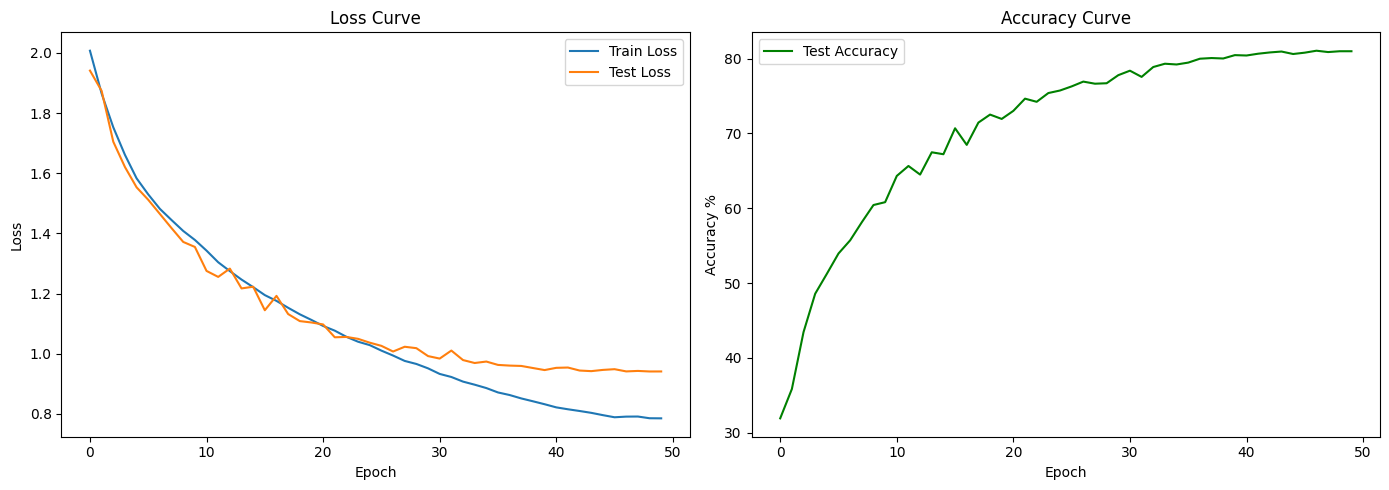

In [7]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    correct    = 0
    total      = 0
    test_loss  = 0.0
    class_correct = [0] * 10
    class_total   = [0] * 10

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            test_loss     += loss.item()
            _, predicted   = outputs.max(1)
            total         += labels.size(0)
            correct       += predicted.eq(labels).sum().item()

            for i in range(labels.size(0)):
                label                    = labels[i].item()
                class_correct[label]    += (predicted[i] == labels[i]).item()
                class_total[label]      += 1

    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total

    print(f"\nOverall Accuracy: {accuracy:.2f}% | Loss: {avg_loss:.4f}\n")

    for i in range(10):
        print(f"{classes[i]:>10s}: {100 * class_correct[i] / class_total[i]:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label="Train Loss")
    axes[0].plot(test_losses,  label="Test Loss")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(test_accs, label="Test Accuracy", color="green")
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy %")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

evaluate(model, test_loader, criterion, device)